Focal pixelpitch: [0.1468305124227713, 0.1468305124227713]
The input gaussian light beam waist: 6000um
The init gaussian phase is random generated.
Blink SDK did not construct successfully


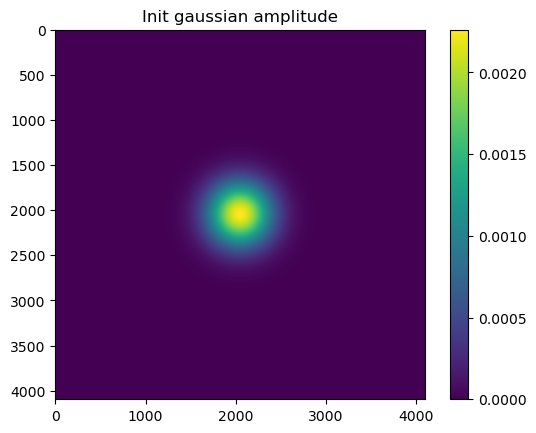

In [144]:
import WGS
import numpy as np
import scipy as sp
import torch
import torch.fft as fft
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from PIL import Image
import os
import time
import json
from Aberration import Zernike
from SLMGeneration import SLM_class
import json
import torch
from BlinkSLM import BlinkSLM
import avt
SLM = SLM_class()

SLM.image_init()

blinkslm=BlinkSLM()
with open("./SLM_config.json") as f:
    config = json.load(f)
    array_size = np.flip(np.array(config["arraysize"]))


Focal pixelpitch: [0.1468305124227713, 0.1468305124227713]
The input gaussian light beam waist: 6000um
The init gaussian phase is random generated.


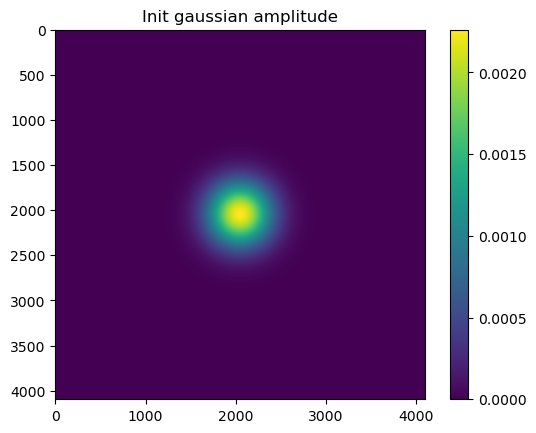

In [145]:
SLM.image_init(initGaussianPhase_user_defined = None, initGaussianPhase_save = False, Plot = True)
initSLMAmp=SLM.initGaussianAmp
# initSLMAmp=torch.from_numpy(initSLMAmp).float()  # 如果需要的话，可以改为 .double()
# initSLMPhase=np.random.rand(initSLMAmp.ImgResX, initSLMAmp.ImgResY)*2*np.pi-np.pi
plt.show()

In [146]:
from PIL import Image

def shrink_by_half_and_pad_4096(img_path, save_path):
    # 1) 打开原图
    img = Image.open(img_path)
    
    # 2) 获取原图尺寸
    w, h = img.size
    
    # 3) 计算缩小 2 倍后的尺寸（宽高都除以 2）
    new_w = w // 2
    new_h = h // 2
    
    # 4) 按 new_w, new_h 进行缩小
    #    如果想要更好的缩放效果，可以使用 BICUBIC、BILINEAR 等插值方式
    img_shrunk = img.resize((new_w, new_h), resample=Image.BICUBIC)
    
    # 5) 创建一个 4096×4096 的黑色画布
    canvas = Image.new("RGB", (4096, 4096), color=(0, 0, 0))
    
    # 6) 计算在画布上贴图的左上角坐标，使图像居中
    left = (4096 - new_w) // 2
    top = (4096 - new_h) // 2
    
    # 7) 把缩放后的图贴到画布 (left, top) 位置
    canvas.paste(img_shrunk, (left, top))
    
    # 8) 保存结果
    canvas.save(save_path)
    print(f"Saved padded image to: {save_path}")


if __name__ == "__main__":
    # 假设有一张图片 test.jpg
    shrink_by_half_and_pad_4096("2.jpg", "3.jpg")

Saved padded image to: 3.jpg


(4096, 4096)


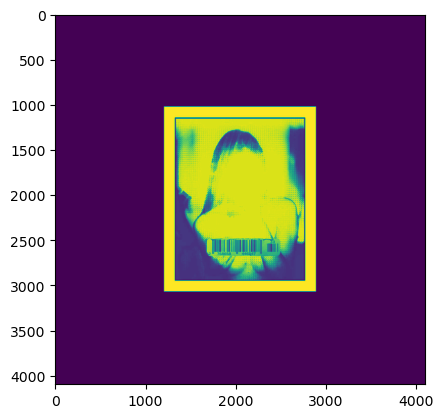

In [147]:
from PIL import Image
import numpy as np

# 1. 打开图像
image_path = "3.jpg"  # 替换为你的图片路径
img = Image.open(image_path)

# 2. 如果想转换为灰度图像，可使用 convert("L")；如果保留原通道，可注释掉这一行
img = img.convert("L")

# 3. 调整大小为 (4096, 4096)
img_resized = img.resize((4096, 4096))

# 4. 转换为 NumPy 数组
img_array = np.array(img_resized)

print(img_array.shape)

plt.imshow(img_array)
# 如果使用了 convert("L") 转为灰度，那么输出应为 (4096, 4096)

In [148]:
targetAmp=img_array

In [149]:
def simple_GS(initSLMAmp, initSLMPhase, targetAmp, num_iter=5):
    """
    不做全局能量归一的最基础 GS 迭代示例
    仅用于演示核心思路
    """
    device = initSLMAmp.device
    # SLM initial field: amplitude fixed, phase = initSLMPhase
    # shape: (H, W)
    SLM_Field = initSLMAmp * torch.exp(1j * initSLMPhase)

    for i in range(num_iter):
        # 1) 前向傅里叶变换到目标面
        Focal_Field = fft.fft2(SLM_Field)
        Focal_Field_shift = fft.fftshift(Focal_Field)

        # 2) 替换成期望幅度 + 保留当前相位
        Focal_Phase = torch.angle(Focal_Field_shift)
        Focal_Field_shift = targetAmp * torch.exp(1j * Focal_Phase)

        # 3) 逆傅里叶变换回 SLM 面
        Focal_Field = fft.ifftshift(Focal_Field_shift)
        SLM_Field_new = fft.ifft2(Focal_Field)

        # 4) 如果是纯相位 SLM，只保留相位，把幅度改回 initSLMAmp
        SLM_Phase = torch.angle(SLM_Field_new)
        SLM_Field = initSLMAmp * torch.exp(1j * SLM_Phase)

    # 最终得到的相位为
    final_phase = torch.angle(SLM_Field)
    return final_phase

In [150]:
input_shape = (4096, 4096)  # 输入振幅分布的尺寸

RandomPhase = torch.rand(input_shape, dtype=torch.float32) * 2 * np.pi - np.pi
SLM_Phase=simple_GS(torch.tensor(initSLMAmp), torch.tensor(RandomPhase), torch.from_numpy(targetAmp),num_iter=10)
# SLM_Phase=WGS.WGS_phase_generate(torch.tensor(initSLMAmp), torch.tensor(RandomPhase), torch.from_numpy(targetAmp), Loop=20, threshold=0.01, Plot=True)
SLM_screen=SLM.phase_to_screen(SLM_Phase.cpu().clone().numpy())

C:\Users\Demeter\AppData\Local\Temp\ipykernel_25504\477597445.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  SLM_Phase=simple_GS(torch.tensor(initSLMAmp), torch.tensor(RandomPhase), torch.from_numpy(targetAmp),num_iter=10)


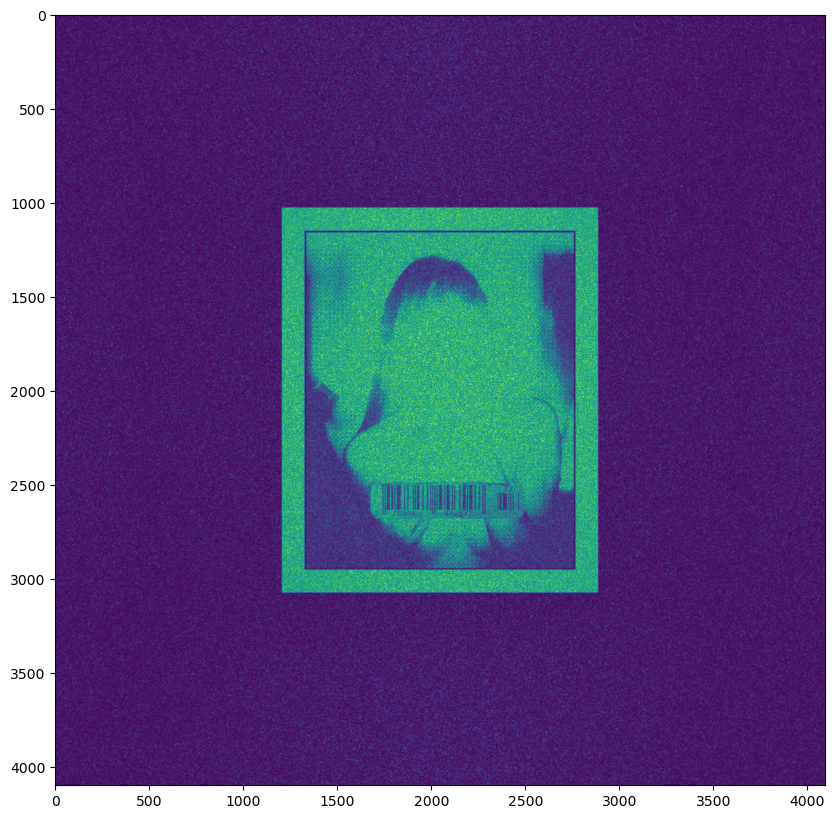

In [151]:

SLM_screen=SLM.phase_to_screen(SLM_Phase.cpu().clone().numpy())
fftAmp,fftPhase = SLM.phase_to_fftField(SLM_Phase.cpu())
plt.figure(figsize=(10,10))
plt.imshow(fftAmp[0:4096,0:4096])
plt.show()

In [161]:
blinkslm.slm_lib.Delete_SDK()
# blinkslm=BlinkSLM()
# blinkslm.write_image((SLM_screen).astype('uint8'))

1

In [153]:
blinkslm=BlinkSLM()

# cdll.LoadLibrary("C:\\Program Files\\Meadowlark Optics\\Blink Plus\\SDK\\Blink_C_wrapper.dll")
# slm_lib = CDLL("Blink_C_wrapper")
# blinkslm.slm_lib.Delete_SDK()

blinkslm.write_image(np.zeros((1024,1024)).astype('uint8'))
blinkslm.slm_lib.Delete_SDK()


Blink SDK was successfully constructed
Found 1 SLM controller(s)


1

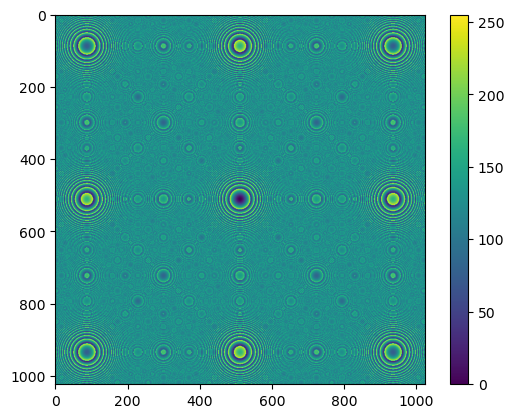

In [156]:
fresnel_lens_screen, _ = SLM.fresnel_lens_phase_generate(1000,1024/2,1024/2)
plt.imshow(fresnel_lens_screen)
plt.colorbar()
plt.show()

In [160]:
blinkslm=BlinkSLM()
blinkslm.write_image((SLM_screen).astype('uint8'))

Blink SDK was successfully constructed
Found 1 SLM controller(s)
